In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.patches as mpatches

In [3]:
#中间矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m, B, a):
    return (m + 4*B/(a**2)) * sz

def h_x(B, a, A):
    return ((-B/(a**2))*sz - (1j/2)*A*sx) 
    
def h_y(B, a, A, Bz,xweizhi):
    return ((-B/(a**2))*sz - (1j/2)*A*sy) * np.exp(-(2*np.pi*1j*a**2)*Bz*xweizhi)

def h_onstie(m, B, a, u):
    return h_k(m, B, a) - u*s0

def t_x(B, a, A):
    return h_x(B, a, A)

def t_y(B, a, A, Bz, xweizhi):
    return h_y(B, a, A, Bz, xweizhi)


def H_onstie(m, B, a, u_set, xshumu, Nd, A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        H[i][i] = h_onstie(m, B, a, u_set[i])

        if i < xshumu - 1:
            H[i][i+1] = t_x(B, a, A)

        if i > 0:
            H[i][i-1] = t_x(B, a, A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B, a, A, xshumu, Nd,Bz):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]

    for i in range(xshumu):
        xweizhi=i
        H[i][i] = t_y(B, a, A, Bz,xweizhi)

    H = np.block(H)
    return H


m = -0.5       # 质量项
A = 1.0        # 费米速度项
B = 0.5        # 二阶动量项
Bz = 0.0  # 磁场
Ex = 0         # 电场相关

a = 1          # 晶格常数
yshumu = 10
xshumu = yshumu

uS = 0
uS_set = []
for i in range(xshumu):
    uS_set.append(uS - Ex * 1 * (i - xshumu/2))

uS_set_base = np.array(uS_set)

Nd = 2


H_q=H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)

H_q_list = []
for i in range(yshumu):
    H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
    H_q_list.append(H_q_i)

T_21 = H_hop(B, a, A, xshumu, Nd,Bz)


if m * B < 0:
    leiN = 1  # Topological
else:
    leiN = 0  # Trivial




In [4]:
## 两边纳米线 
t = 1
tc = 0.2 * t
mu = 2.5
weidu = 2
kuandu = 10  # 电极的横向宽度
Nd = 2        # 2x2 正常态

def H_onsite_1(t,mu ,weidu):
    HX_block = -(mu - 2*weidu*t)*s0 
    return HX_block

def H_hop_1(t):
    # 纯粹的最近邻跳跃
    H_X_right_to_left_hop_block = -t * s0
    return H_X_right_to_left_hop_block

def H_onsite_2(t,mu, weidu, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):
        H[i][i] = H_onsite_1(t,mu, weidu)


        if i < kuandu - 1:
            H[i][i+1] = H_hop_1(t)
        if i > 0:
            H[i][i-1] = H_hop_1(t).conj().T
    
    return np.block(H)

def H_hop_2(t, kuandu):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(kuandu)] for _ in range(kuandu)]

    for i in range(kuandu):

        H[i][i] = H_hop_1(t)

    return np.block(H)

# 矩阵信息

H_l = H_onsite_2(t,mu, weidu, kuandu)
T_l = H_hop_2(t, kuandu)

H_r = H_onsite_2(t,mu, weidu, kuandu)
T_r = H_hop_2(t, kuandu).conj().T


#整体耦合块
T_c = H_hop_2(tc, kuandu) 

# 左电极耦合矩阵
T_LD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_LD[:, -Nd * kuandu:] = T_c.conj().T

# 右电极耦合矩阵
T_RD = np.zeros((Nd * kuandu, Nd * xshumu), dtype=complex)
T_RD[:, :Nd * kuandu] = T_c

print(f"2D 左电极 H_l 维度: {H_l.shape}")
print(f"左侧耦合矩阵 T_LD 维度: {T_LD.shape}")
#print(T_RD)

2D 左电极 H_l 维度: (20, 20)
左侧耦合矩阵 T_LD 维度: (20, 20)


In [5]:
#function
#T_l不可逆
def gr_L_keni(T_l, A_l, tol=1e-16):
    N = T_l.shape[0]
    I = np.eye(N)

    A = np.block([
        [np.zeros((N, N)), I],
        [-T_l.conj().T, A_l]
    ])

    B = np.block([
        [I, np.zeros((N, N))],
        [np.zeros((N, N)), T_l]
    ])

    eigvals, eigvecs = eig(A, B)

    lambdas = []
    modes = []

    for i, lam in enumerate(eigvals):
        if np.abs(lam) < 1 - tol:   # 衰减模式
            x = eigvecs[:N, i]
            x /= np.linalg.norm(x)
            lambdas.append(lam)
            modes.append(x)

    X = np.column_stack(modes)
    Lambda = np.diag(lambdas)
    #print(Lambda.shape,X.shape)
    F = X @ Lambda @ np.linalg.inv(X)

    gL = np.linalg.inv(A_l - T_l @ F)

    return gL

def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    #check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    #max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, Sigma_virtual_big, eta=1e-6):
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 这里应该是单层的维度 (例如 4 * xshumu 或 2 * xshumu)
    d_lead = H_l.shape[0]            # 电极维度，例如 4 或 2
    
    I_device = np.eye(d_device, dtype=complex)
    Z = np.zeros((d_device, d_device), dtype=complex)

    # 注意：电极和中心区的维度不同，需要分别构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ------------- 构建总格林函数矩阵 A_DD -------------
    A_DD = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        # 从列表中取出对应 yweizhi (即 i) 的 H_q
        H_q_i = H_q_list[i]

        # 把真实引线的自能加在边界层
        if i == 0:
            A_DD[i][i] = EI_device - H_q_i - Sigma_L
        elif i == yshumu-1:
            A_DD[i][i] = EI_device - H_q_i - Sigma_R
        else:
            A_DD[i][i] = EI_device - H_q_i

        # 加上层间跃迁
        if i < yshumu-1:
            A_DD[i][i+1] = -T_21
        if i > 0:
            A_DD[i][i-1] = -T_21.conj().T
            
    # 将列表分块矩阵拼成一个完整的二维大矩阵
    A_DD = np.block(A_DD)
    
    # ==========================================
    # 核心修改：引入退相干效应
    # 减去全器件维度的虚拟探针自能大矩阵 Sigma_virtual_big
    # ==========================================
    A_DD = A_DD - Sigma_virtual_big
    
    # 对全矩阵求逆，得到包含退相干效应的总推迟格林函数
    G_DD_r = np.linalg.inv(A_DD)
    
    return G_DD_r, Sigma_R, Sigma_L

#新函数
def Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=1e-6):
    N = yshumu
    
    # 动态获取器件和电极的矩阵维度
    d_device = H_q_list[0].shape[0]  # 这里是 4 * xshumu = 160
    d_lead = H_l.shape[0]            # 电极维度，这里是 4
    
    I_device = np.eye(d_device, dtype=complex)
    
    # 构建能量对角阵
    EI_lead = (E + 1j*eta) * np.eye(d_lead, dtype=complex)
    EI_device = (E + 1j*eta) * I_device

    # ---------------- 计算左电极自能 ----------------
    A_l = EI_lead - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    # ---------------- 计算右电极自能 ----------------
    A_r = EI_lead - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)

    # ==========================================
    # 核心修改：使用 RGF 算法直接计算非对角块 G_RL
    # ==========================================
    V = T_21
    V_dagger = V.conj().T
    
    # gL 数组存储从左向右扫描的局域有效格林函数
    gL = np.zeros((N, d_device, d_device), dtype=complex)
    
    # 1. 第 0 层 (最左侧)：包含本层哈密顿量和左电极自能
    gL[0] = np.linalg.inv(EI_device - H_q_list[0] - Sigma_L)
    
    # 2. 中间层：通过 Dyson 方程，把左侧所有层的物理效应折叠为本层的等效自能
    for n in range(1, N-1):
        Sigma_eff_L = V_dagger @ gL[n-1] @ V
        gL[n] = np.linalg.inv(EI_device - H_q_list[n] - Sigma_eff_L)
        
    # 3. 第 N-1 层 (最右侧)：包含左侧传播来的等效自能，以及真实的右电极自能
    Sigma_eff_L_last = V_dagger @ gL[N-2] @ V
    gL[N-1] = np.linalg.inv(EI_device - H_q_list[N-1] - Sigma_eff_L_last - Sigma_R)
    
    # 4. 回溯提取透射矩阵 G_RL (即 G_{N-1, 0}，波函数从左侧 0 传播到右侧 N-1)
    G_RL = gL[N-1].copy()
    for n in range(N-2, -1, -1):
        G_RL = G_RL @ V_dagger @ gL[n]

    # 直接返回这三个计算电导的必需品，G_RL 的维度是 160x160
    return G_RL, Sigma_R, Sigma_L

In [6]:
E = 0.25
T_d = 0.05 * np.array([[1, 0], [0, 1]], dtype=complex)

xushuzineng = -1j * T_d / 2
total_sites = xshumu * yshumu
M = total_sites * 2  
Sigma_virtual_big = np.kron(np.eye(total_sites, dtype=complex), xushuzineng)
G_all, Sigma_R, Sigma_L = Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, Sigma_virtual_big, eta=1e-6)


d_device = Sigma_L.shape[0]  # 获取左电极单层截面的维度

# ==========================================
# 1. 动态索引与致密小矩阵提取 (极速优化的核心)
# ==========================================
# 我们约定引线编号 (Probe Index)：
# 0                 : 左极 (源极)
# 1 到 total_sites  : 中间的虚拟探针
# total_sites + 1   : 右极 (漏极)

slices = []         # 记录每个引线在 G_all 大矩阵中的 (起始索引, 结束索引)
small_gammas = []   # 记录每个引线局部的致密展宽矩阵 (不补零)

# --- (0) 左电极 (源极) ---
gamma_L_small = 1j * (Sigma_L - Sigma_L.conj().T)
slices.append((0, d_device))
small_gammas.append(gamma_L_small)

# --- (1 到 N) 虚拟探针 ---
for i in range(total_sites):
    slices.append((2 * i, 2 * i + 2))
    small_gammas.append(T_d)  # 虚拟探针的展宽就是 T_d

# --- (N+1) 右电极 (漏极) ---
gamma_R_small = 1j * (Sigma_R - Sigma_R.conj().T)
slices.append((M - d_device, M))
small_gammas.append(gamma_R_small)

num_probes = len(slices)  # 总引线数量 = total_sites + 2

# ==========================================
# 2. 极速计算透射矩阵 T_ij
# ==========================================
print(f"开始极速计算 {num_probes}x{num_probes} 的透射矩阵 T_ij ...")
T_matrix = np.zeros((num_probes, num_probes), dtype=float)

for i in range(num_probes):
    start_i, end_i = slices[i]
    gamma_i = small_gammas[i]
    
    for j in range(num_probes):
        if i == j:
            continue  # 同一个引线对自己的透射不需要算
        
        start_j, end_j = slices[j]
        gamma_j = small_gammas[j]
        
        # 核心优化：只截取 G_all 中非零的局域格林函数小块 (比如 2x20)
        G_ij = G_all[start_i:end_i, start_j:end_j]
        
        # 修复报错：Ga_ji 是 G^a 的 (j,i) 块，它严格等于 G_ij 的共轭转置 (维度自动变为 20x2)
        Ga_ji = G_ij.conj().T
        
        # 微型矩阵求迹：Tr(Gamma_i * G_ij * Gamma_j * Ga_ji)
        # 维度链条: (2x2) @ (2x20) @ (20x20) @ (20x2) -> 最终是完美的 (2x2) 矩阵求迹！
        T_matrix[i, j] = np.real(np.trace(gamma_i @ G_ij @ gamma_j @ Ga_ji))

print("T_ij 计算完成！")

# ==========================================
# 3. 解 Büttiker 虚拟电压方程 (求解净电流 J = 0)
# ==========================================
# 我们设定左端偏压 V_L = 1.0, 右端偏压 V_R = 0.0
V_L = 1.0
V_R = 0.0

W = np.zeros((total_sites, total_sites), dtype=float)
B_vec = np.zeros(total_sites, dtype=float)

for p in range(1, total_sites + 1):  
    row = p - 1  
    
    W[row, row] = np.sum(T_matrix[p, :])
    
    for q in range(1, total_sites + 1):
        if p != q:
            col = q - 1
            W[row, col] = -T_matrix[p, q]
            
    # B向量注入源
    B_vec[row] = T_matrix[p, 0] * V_L + T_matrix[p, num_probes - 1] * V_R

V_virtual = np.linalg.solve(W, B_vec)

# ==========================================
# 4. 计算包含退相干效应的总等效电导 (T_eff)
# ==========================================
T_eff = T_matrix[0, num_probes - 1] * (V_L - V_R) 

for v in range(1, total_sites + 1):
    T_eff += T_matrix[0, v] * (V_L - V_virtual[v - 1])


开始极速计算 102x102 的透射矩阵 T_ij ...
T_ij 计算完成！


开始扫描磁场 Bz，共 100 个点...


Calculating T_eff: 100%|██████████| 100/100 [00:17<00:00,  5.84it/s]


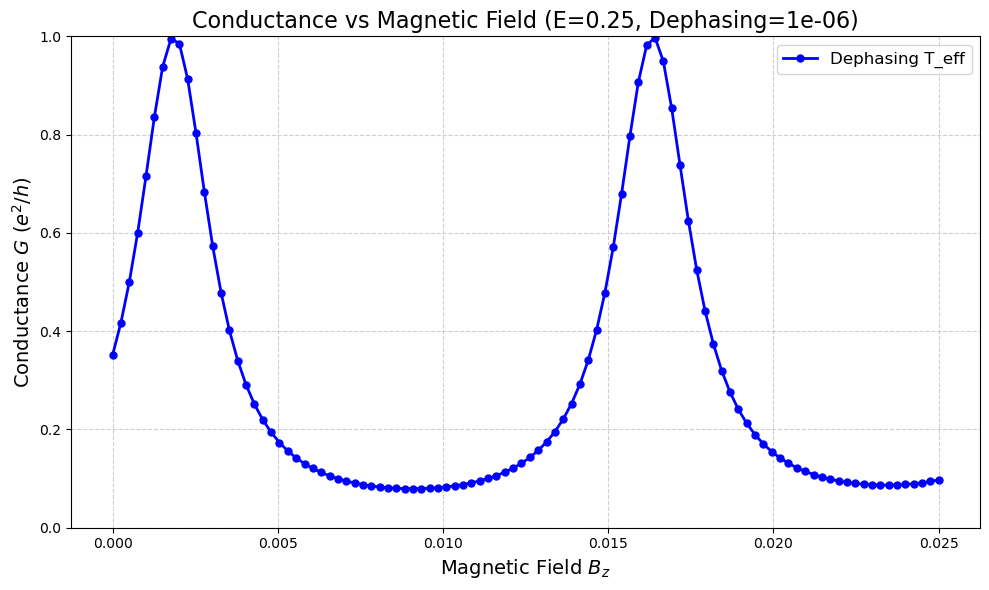

In [7]:

# ==========================================
# 1. 提取全局常量 (放在循环外，极大地提升速度)
# ==========================================
E = 0.25
T_d = 1e-6* np.array([[1, 0], [0, 1]], dtype=complex)
xushuzineng = -1j * T_d / 2

total_sites = xshumu * yshumu
M = total_sites * 2  

# 提前生成固定不变的全器件虚拟自能矩阵
Sigma_virtual_big = np.kron(np.eye(total_sites, dtype=complex), xushuzineng)

# (注意：假设你已经在外部定义了 H_l, H_r, T_LD, T_RD, T_l, T_r 等电极矩阵)
# 如果这些电极随 Bz 改变，需要放到下面的函数里！这里假设它们不变。

# ==========================================
# 2. 核心计算函数：输入 Bz，返回 T_eff
# ==========================================
def calc_T_eff(Bz_val,E):
    # 1. 动态更新层间跃迁矩阵 (带入当前的磁场 Bz_val)
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_val)
    
    # 2. 计算格林函数 (注意传入全局的 Sigma_virtual_big)
    G_all, Sigma_R, Sigma_L = Gr_DD(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, Sigma_virtual_big, eta=1e-6)
    
    d_device = Sigma_L.shape[0] 
    
    # 3. 提取非零小矩阵块
    slices = []
    small_gammas = []
    
    gamma_L_small = 1j * (Sigma_L - Sigma_L.conj().T)
    slices.append((0, d_device))
    small_gammas.append(gamma_L_small)
    
    for i in range(total_sites):
        slices.append((2 * i, 2 * i + 2))
        small_gammas.append(T_d)
        
    gamma_R_small = 1j * (Sigma_R - Sigma_R.conj().T)
    slices.append((M - d_device, M))
    small_gammas.append(gamma_R_small)
    
    num_probes = len(slices)
    
    # 4. 极速计算透射矩阵 T_ij
    T_matrix = np.zeros((num_probes, num_probes), dtype=float)
    for i in range(num_probes):
        start_i, end_i = slices[i]
        gamma_i = small_gammas[i]
        for j in range(num_probes):
            if i == j: continue 
            start_j, end_j = slices[j]
            gamma_j = small_gammas[j]
            
            G_ij = G_all[start_i:end_i, start_j:end_j]
            Ga_ji = G_ij.conj().T
            T_matrix[i, j] = np.real(np.trace(gamma_i @ G_ij @ gamma_j @ Ga_ji))

    # 5. 解 Büttiker 虚拟电压方程
    V_L = 1.0
    V_R = 0.0
    W = np.zeros((total_sites, total_sites), dtype=float)
    B_vec = np.zeros(total_sites, dtype=float)
    
    for p in range(1, total_sites + 1):  
        row = p - 1  
        W[row, row] = np.sum(T_matrix[p, :])
        for q in range(1, total_sites + 1):
            if p != q:
                col = q - 1
                W[row, col] = -T_matrix[p, q]
        B_vec[row] = T_matrix[p, 0] * V_L + T_matrix[p, num_probes - 1] * V_R

    V_virtual = np.linalg.solve(W, B_vec)

    # 6. 整合有效电导 T_eff
    T_eff = T_matrix[0, num_probes - 1] * (V_L - V_R) 
    for v in range(1, total_sites + 1):
        T_eff += T_matrix[0, v] * (V_L - V_virtual[v - 1])
        
    return T_eff

# ==========================================
# 3. 扫描磁场并绘制曲线
# ==========================================
num_points = 100
Bz_values = np.linspace(0, 0.025, num_points)
T_eff_results = []

print(f"开始扫描磁场 Bz，共 {num_points} 个点...")

# 使用 tqdm 循环以便直观查看进度和预估剩余时间
for Bz in tqdm(Bz_values, desc="Calculating T_eff"):
    teff = calc_T_eff(Bz,E)
    T_eff_results.append(teff)

# 转化为 numpy 数组方便处理
T_eff_results = np.array(T_eff_results)

# 绘制最终的物理图像
plt.figure(figsize=(10, 6))
plt.plot(Bz_values, T_eff_results, 'bo-', linewidth=2, markersize=5, label='Dephasing T_eff')
plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(f'Conductance vs Magnetic Field (E={E}, Dephasing={T_d[0,0].real})', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.ylim(0,1)
plt.show()

# 如果你想保留数据，可以顺手保存
# np.savetxt("T_eff_vs_Bz_Dephasing.txt", np.column_stack((Bz_values, T_eff_results)), header="Bz T_eff")

固定 E = 0.25, 开始使用 RGF 算法扫描磁场 Bz 并计算电导 (启动 14 进程并行计算)...


Scanning Bz (Parallel): 100%|██████████| 2501/2501 [00:01<00:00, 2176.02it/s]


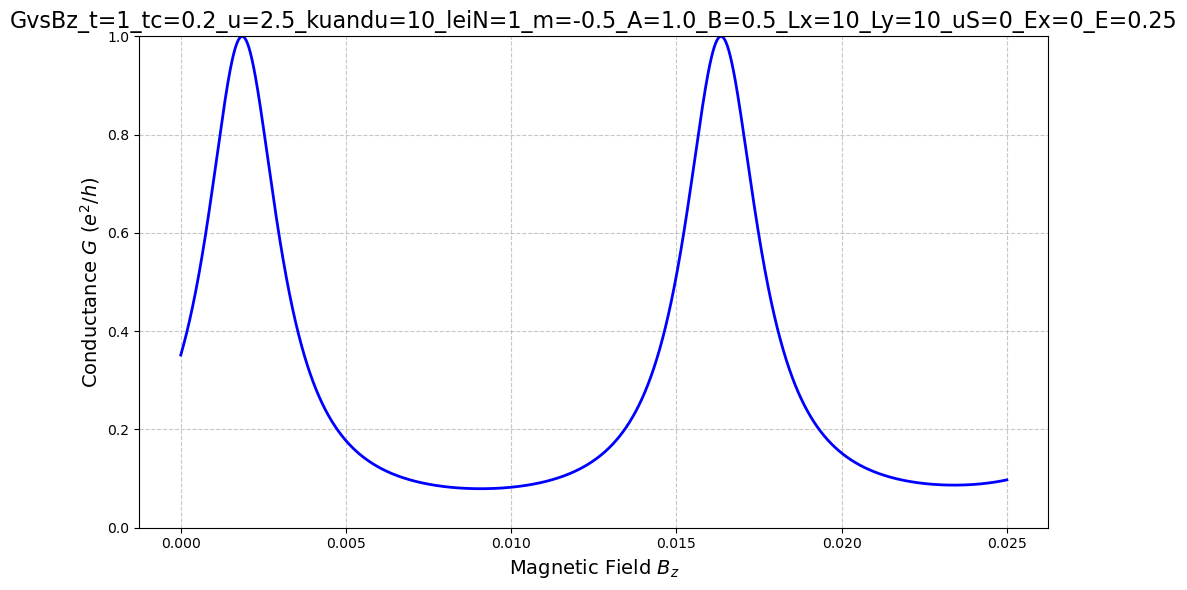

In [11]:
# 设定固定的 E 和要扫描的 Bz 范围 多核心计算
E = 0.25
Bz0 = 0
Bz1 = 0.025
dianshu = 2501
Bz_values = np.linspace(Bz0, Bz1, dianshu)
eta = 1e-6
T_d = 0.0* np.array([[1, 0], [0, 1]], dtype=complex)
xushuzineng = -1j * T_d / 2
Sigma_virtual_big = np.kron(np.eye(total_sites, dtype=complex), xushuzineng)
# 定义保存路径
save_dir = rf"D:\结果\2026.4.27"
params_str_1 = f"t={t}_tc={tc}_u={mu}_kuandu={kuandu}_leiN={leiN}_m={m}_A={A}_B={B}_Lx={xshumu}_Ly={yshumu}_uS={uS}_Ex={Ex}_E={E}"


print(f"固定 E = {E}, 开始使用 RGF 算法扫描磁场 Bz 并计算电导 (启动 14 进程并行计算)...")

# ==========================================
# 核心修改：将循环内的计算逻辑打包成一个独立函数
# ==========================================
def calc_single_Bz_2(Bz_1):
    H_q_list = []
    for i in range(yshumu):
        H_q_i = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A)
        H_q_list.append(H_q_i)
    T_21 = H_hop(B, a, A, xshumu, Nd, Bz_1)

    # ⚠️ 如果正式算磁场，记得这里要更新右电极！(遵照你的要求，这里保持注释状态不动)
    # H_r = H_onstie(m, B, a, uS_set_base, xshumu, Nd, A, Bz_1, yshumu)

    G_RL, Sigma_R, Sigma_L = Gr_DD_2(H_q_list, H_l, H_r, T_21, T_LD, T_l, T_RD, T_r, yshumu, E, eta=eta)

    zhankuanL = 1j * (Sigma_L - Sigma_L.conj().T)
    zhankuanR = 1j * (Sigma_R - Sigma_R.conj().T)

    G_complex = np.trace(zhankuanR @ G_RL @ zhankuanL @ G_RL.conj().T)
    G_real = np.real(G_complex)
    
    return G_real

G_values = Parallel(n_jobs=14)(
    delayed(calc_single_Bz_2)(Bz_1) for Bz_1 in tqdm(Bz_values, desc="Scanning Bz (Parallel)")
)

# ----------------- 画图部分 -----------------
plt.figure(figsize=(10, 6)) 
plt.plot(Bz_values, G_values, linestyle='-', color='b', linewidth=2)

plt.xlabel(r'Magnetic Field $B_z$', fontsize=14)
plt.ylabel(r'Conductance $G \ (e^2/h)$', fontsize=14)
plt.title(fr'GvsBz_{params_str_1}', fontsize=16)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()


# 保存图片
#save_fig_by_title_1('G_vs_Bz_' + params_str_1)

# ----------------- 保存数据部分 -----------------
# 调用刚才写好的数据保存函数
if 3==2:
    save_data_to_txt(
        x_data=Bz_values, 
        y_data=G_values, 
        filename='G_vs_Bz_shuju_' + params_str_1, 
        save_dir=save_dir,
        header_text="Bz\tConductance_G"
    )

# 显示图像
plt.ylim(0,1)
plt.show()

In [9]:

from scipy.integrate import simpson  # 如果你想用更高精度的积分方法

def calculate_area_under_curve(x_data, y_data):
    """
    计算给定 x 和 y 离散数据点下方的面积
    """
    # 确保数据是 numpy 数组
    x_array = np.array(x_data)
    y_array = np.array(y_data)
    
    # 方法一：梯形积分法 (Trapezoidal rule)
    # 这是最基础、最稳妥的方法，通过把相邻点连成梯形来求面积
    area_trapz = np.trapz(y_array, x=x_array)
    
    # 方法二：辛普森积分法 (Simpson's rule)
    # 通过二次多项式拟合相邻的三个点，对于平滑的物理曲线（如电导平台）精度通常更高
    area_simps = simpson(y=y_array, x=x_array)
    
    return area_trapz, area_simps

# ==========================================
# 调用函数计算你跑出来的 Bz_values 和 T_eff_results 的面积
# ==========================================
# 假设 T_eff_results 和 Bz_values 已经是你循环跑完后的数组
area_t, area_s = calculate_area_under_curve(Bz_values,  G_values)

print("\n--- 面积计算结果 ---")
print(f"梯形法计算的面积: {area_t:.6f}")
print(f"辛普森法计算的面积: {area_s:.6f}")


--- 面积计算结果 ---
梯形法计算的面积: 0.007570
辛普森法计算的面积: 0.007570
